# This project uses the 'base' anaconda environment

In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import scipy.stats as stats
import re

In [6]:
import category_encoders as ce

# Importing the Dataset

## Aims and Objectives: 





## Data Description
<b>Columns:</b>
- Loan_ID = unique identifier
- Gender = male, female
- Married = Yes, no
- Depdendents = how many people depend on this person 
- Education = Graduate / Not Graduate
- Self_employed = yes/no
- Applicant income = income of the applicant
- coapplicant income = income of an additional applicant
- credit history = 1 / 0
- property_area = Urban / SemiUrban / Rural
- loan status = Approved / UnApproved loan

## Data Source
https://www.kaggle.com/datasets/sonalisingh1411/loan-approval-prediction?select=Training+Dataset.csv

## Key Questions 

1. What factors are most important to getting loan approval? 

In [7]:
train = pd.read_csv("~/loan_dataset/data/training.csv")
test = pd.read_csv("~/loan_dataset/data/test.csv")


In [8]:
train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [9]:
test.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [10]:
df = pd.concat([train, test], axis=0)

In [11]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777.0,113.0,360.0,1.0,Urban,NaN
363,LP002975,Male,Yes,0,Graduate,No,4158,709.0,115.0,360.0,1.0,Urban,NaN
364,LP002980,Male,No,0,Graduate,No,3250,1993.0,126.0,360.0,NaN,Semiurban,NaN
365,LP002986,Male,Yes,0,Graduate,No,5000,2393.0,158.0,360.0,1.0,Rural,NaN


Sorting the dataframe by the Loan_ID

In [12]:
df = df.sort_values(['Loan_ID'])

In [13]:
df.shape

(981, 13)

# Data Cleaning

checking for...
- Missing values
- duplicated rows 
- erroneous values
- summary statistics
- Column names

In [14]:
df.columns

df.columns = df.columns.str.lower() 
df.columns

Index(['loan_id', 'gender', 'married', 'dependents', 'education', 'self_employed', 'applicantincome', 'coapplicantincome', 'loanamount',
       'loan_amount_term', 'credit_history', 'property_area', 'loan_status'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 981 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loan_id            981 non-null    object 
 1   gender             957 non-null    object 
 2   married            978 non-null    object 
 3   dependents         956 non-null    object 
 4   education          981 non-null    object 
 5   self_employed      926 non-null    object 
 6   applicantincome    981 non-null    int64  
 7   coapplicantincome  981 non-null    float64
 8   loanamount         954 non-null    float64
 9   loan_amount_term   961 non-null    float64
 10  credit_history     902 non-null    float64
 11  property_area      981 non-null    object 
 12  loan_status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 107.3+ KB


In [16]:
df.dependents.unique()

array(['0', '1', '2', '3+', nan], dtype=object)

In [17]:
df.isna().sum()

loan_id                0
gender                24
married                3
dependents            25
education              0
self_employed         55
applicantincome        0
coapplicantincome      0
loanamount            27
loan_amount_term      20
credit_history        79
property_area          0
loan_status          367
dtype: int64

In [18]:
df[df.loan_status.isna() == True]

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,LP001015,Male,Yes,0,Graduate,No,5720,0.0,110.0,360.0,1.0,Urban,NaN
1,LP001022,Male,Yes,1,Graduate,No,3076,1500.0,126.0,360.0,1.0,Urban,NaN
2,LP001031,Male,Yes,2,Graduate,No,5000,1800.0,208.0,360.0,1.0,Urban,NaN
3,LP001035,Male,Yes,2,Graduate,No,2340,2546.0,100.0,360.0,NaN,Urban,NaN
4,LP001051,Male,No,0,Not Graduate,No,3276,0.0,78.0,360.0,1.0,Urban,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777.0,113.0,360.0,1.0,Urban,NaN
363,LP002975,Male,Yes,0,Graduate,No,4158,709.0,115.0,360.0,1.0,Urban,NaN
364,LP002980,Male,No,0,Graduate,No,3250,1993.0,126.0,360.0,NaN,Semiurban,NaN
365,LP002986,Male,Yes,0,Graduate,No,5000,2393.0,158.0,360.0,1.0,Rural,NaN


In [19]:
df[df.credit_history.isna() == True]

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
16,LP001034,Male,No,1,Not Graduate,No,3596,0.0,100.0,240.0,NaN,Urban,Y
3,LP001035,Male,Yes,2,Graduate,No,2340,2546.0,100.0,360.0,NaN,Urban,NaN
24,LP001052,Male,Yes,1,Graduate,NaN,3717,2925.0,151.0,360.0,NaN,Semiurban,N
12,LP001083,Male,No,3+,Graduate,No,4166,0.0,40.0,180.0,NaN,Urban,NaN
30,LP001091,Male,Yes,1,Graduate,NaN,4166,3369.0,201.0,360.0,NaN,Urban,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,LP002901,Male,No,0,Graduate,No,2283,15000.0,106.0,360.0,NaN,Rural,NaN
600,LP002949,Female,No,3+,Graduate,NaN,416,41667.0,350.0,180.0,NaN,Urban,N
358,LP002954,Male,Yes,2,Not Graduate,No,3132,0.0,76.0,360.0,NaN,Rural,NaN
360,LP002965,Female,Yes,0,Graduate,No,8550,4255.0,96.0,360.0,NaN,Urban,NaN


In [20]:
df[df.loan_amount_term.isna() == True]

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
19,LP001041,Male,Yes,0,Graduate,NaN,2600,3500.0,115.0,NaN,1.0,Urban,Y
36,LP001109,Male,Yes,0,Graduate,No,1828,1330.0,100.0,NaN,0.0,Urban,N
44,LP001136,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,NaN,1.0,Urban,Y
45,LP001137,Female,No,0,Graduate,No,3410,0.0,88.0,NaN,1.0,Urban,Y
45,LP001232,Male,Yes,0,Graduate,No,4260,3900.0,185.0,NaN,NaN,Urban,NaN
73,LP001250,Male,Yes,3+,Not Graduate,No,4755,0.0,95.0,NaN,0.0,Semiurban,N
48,LP001268,Male,No,0,Graduate,No,6792,3338.0,187.0,NaN,1.0,Urban,NaN
112,LP001391,Male,Yes,0,Not Graduate,No,3572,4114.0,152.0,NaN,0.0,Rural,N
165,LP001574,Male,Yes,0,Graduate,No,3707,3166.0,182.0,NaN,1.0,Rural,Y
117,LP001611,Male,Yes,1,Graduate,No,1516,2900.0,80.0,NaN,0.0,Rural,NaN


In [21]:
df[df.loanamount.isna() == True]

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
35,LP001106,Male,Yes,0,Graduate,No,2275,2067.0,NaN,360.0,1.0,Urban,Y
63,LP001213,Male,Yes,1,Graduate,No,4945,0.0,NaN,360.0,0.0,Rural,N
81,LP001266,Male,Yes,1,Graduate,Yes,2395,0.0,NaN,360.0,1.0,Semiurban,Y
95,LP001326,Male,No,0,Graduate,NaN,6782,0.0,NaN,360.0,NaN,Urban,N
102,LP001350,Male,Yes,NaN,Graduate,No,13650,0.0,NaN,360.0,1.0,Urban,Y
103,LP001356,Male,Yes,0,Graduate,No,4652,3583.0,NaN,360.0,1.0,Semiurban,Y
113,LP001392,Female,No,1,Graduate,Yes,7451,0.0,NaN,360.0,1.0,Semiurban,Y
78,LP001415,Male,Yes,1,Graduate,No,3413,4053.0,NaN,360.0,1.0,Semiurban,NaN
127,LP001449,Male,No,0,Graduate,No,3865,1640.0,NaN,360.0,1.0,Rural,Y


In [22]:
df[df.self_employed.isna() == True]

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
11,LP001027,Male,Yes,2,Graduate,NaN,2500,1840.0,109.0,360.0,1.0,Urban,Y
19,LP001041,Male,Yes,0,Graduate,NaN,2600,3500.0,115.0,NaN,1.0,Urban,Y
24,LP001052,Male,Yes,1,Graduate,NaN,3717,2925.0,151.0,360.0,NaN,Semiurban,N
8,LP001059,Male,Yes,2,Graduate,NaN,13633,0.0,280.0,240.0,1.0,Urban,NaN
11,LP001082,Male,Yes,1,Graduate,NaN,2185,1516.0,162.0,360.0,1.0,Semiurban,NaN
29,LP001087,Female,No,2,Graduate,NaN,3750,2083.0,120.0,360.0,1.0,Semiurban,Y
30,LP001091,Male,Yes,1,Graduate,NaN,4166,3369.0,201.0,360.0,NaN,Urban,N
13,LP001094,Male,Yes,2,Graduate,NaN,12173,0.0,166.0,360.0,0.0,Semiurban,NaN
36,LP001208,Male,Yes,2,Graduate,NaN,7350,4029.0,185.0,180.0,1.0,Urban,NaN
95,LP001326,Male,No,0,Graduate,NaN,6782,0.0,NaN,360.0,NaN,Urban,N


In [23]:
df[df.gender.isna() == True]

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
23,LP001050,NaN,Yes,2,Not Graduate,No,3365,1917.0,112.0,360.0,0.0,Rural,N
22,LP001128,NaN,No,0,Graduate,No,3909,0.0,101.0,360.0,1.0,Urban,NaN
51,LP001287,NaN,Yes,3+,Not Graduate,No,3500,833.0,120.0,360.0,1.0,Semiurban,NaN
126,LP001448,NaN,Yes,3+,Graduate,No,23803,0.0,370.0,360.0,1.0,Rural,Y
106,LP001563,NaN,No,0,Graduate,No,1596,1760.0,119.0,360.0,0.0,Urban,NaN
171,LP001585,NaN,Yes,3+,Graduate,No,51763,0.0,700.0,300.0,1.0,Urban,Y
188,LP001644,NaN,Yes,0,Graduate,Yes,674,5296.0,168.0,360.0,1.0,Rural,Y
138,LP001769,NaN,No,NaN,Graduate,No,3333,1250.0,110.0,360.0,1.0,Semiurban,NaN
314,LP002024,NaN,Yes,0,Graduate,No,2473,1843.0,159.0,360.0,1.0,Rural,N
334,LP002103,NaN,Yes,1,Graduate,Yes,9833,1833.0,182.0,180.0,1.0,Urban,Y


In [24]:
df[df.married.isna() == True]

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
104,LP001357,Male,NaN,NaN,Graduate,No,3816,754.0,160.0,360.0,1.0,Urban,Y
228,LP001760,Male,NaN,NaN,Graduate,No,4758,0.0,158.0,480.0,1.0,Semiurban,Y
435,LP002393,Female,NaN,NaN,Graduate,No,10047,0.0,NaN,240.0,1.0,Semiurban,Y


In [25]:
df[df.dependents.isna() == True]

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
46,LP001237,Male,Yes,NaN,Not Graduate,No,4163,1475.0,162.0,360.0,1.0,Urban,NaN
102,LP001350,Male,Yes,NaN,Graduate,No,13650,0.0,NaN,360.0,1.0,Urban,Y
104,LP001357,Male,NaN,NaN,Graduate,No,3816,754.0,160.0,360.0,1.0,Urban,Y
70,LP001366,Female,No,NaN,Graduate,No,3250,0.0,95.0,360.0,1.0,Semiurban,NaN
120,LP001426,Male,Yes,NaN,Graduate,No,5667,2667.0,180.0,360.0,1.0,Rural,Y
111,LP001587,Male,Yes,NaN,Graduate,No,4082,0.0,93.0,360.0,1.0,Semiurban,NaN
226,LP001754,Male,Yes,NaN,Not Graduate,Yes,4735,0.0,138.0,360.0,1.0,Urban,N
228,LP001760,Male,NaN,NaN,Graduate,No,4758,0.0,158.0,480.0,1.0,Semiurban,Y
138,LP001769,NaN,No,NaN,Graduate,No,3333,1250.0,110.0,360.0,1.0,Semiurban,NaN
293,LP001945,Female,No,NaN,Graduate,No,5417,0.0,143.0,480.0,0.0,Urban,N


In [26]:
df.duplicated().sum()

0

In [27]:
# Summary Statistics

df.describe()

,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history
count,981.000000,981.000000,954.000000,961.000000,902.000000
mean,5179.795107,1601.916330,142.511530,342.201873,0.835920
std,5695.104533,2718.772806,77.421743,65.100602,0.370553
min,0.000000,0.000000,9.000000,6.000000,0.000000
25%,2875.000000,0.000000,100.000000,360.000000,1.000000
50%,3800.000000,1110.000000,126.000000,360.000000,1.000000
75%,5516.000000,2365.000000,162.000000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [28]:
df.education.unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [29]:
df.credit_history.unique()

array([ 1.,  0., nan])

In [30]:
df.property_area.unique()

array(['Urban', 'Rural', 'Semiurban'], dtype=object)

In [31]:
df.loan_status

0        Y
1        N
2        Y
3        Y
4        Y
      ... 
611      Y
612      Y
365    NaN
366    NaN
613      N
Name: loan_status, Length: 981, dtype: object

In [32]:
df2.loan_status

NameError: name 'df2' is not defined

In [33]:
df

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
365,LP002986,Male,Yes,0,Graduate,No,5000,2393.0,158.0,360.0,1.0,Rural,NaN
366,LP002989,Male,No,0,Graduate,Yes,9200,0.0,98.0,180.0,1.0,Rural,NaN


In [34]:
df.shape

(981, 13)

In [35]:
df.isna().sum()

loan_id                0
gender                24
married                3
dependents            25
education              0
self_employed         55
applicantincome        0
coapplicantincome      0
loanamount            27
loan_amount_term      20
credit_history        79
property_area          0
loan_status          367
dtype: int64

In [36]:
%view df

# EDA

In [37]:
df.head()

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [38]:
df.loan_amount_term.unique()

array([360., 120., 240.,  nan, 180.,  60., 300., 480.,  84.,  12., 350.,  36.,   6.])

Before imputation, I need to encode the variables via preprocessing

In [39]:
df

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
365,LP002986,Male,Yes,0,Graduate,No,5000,2393.0,158.0,360.0,1.0,Rural,NaN
366,LP002989,Male,No,0,Graduate,Yes,9200,0.0,98.0,180.0,1.0,Rural,NaN


In [40]:
df2 = df.dropna()

In [41]:
df2

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [42]:
df2.property_area.unique()

array(['Rural', 'Urban', 'Semiurban'], dtype=object)

In [43]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 480 entries, 1 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loan_id            480 non-null    object 
 1   gender             480 non-null    object 
 2   married            480 non-null    object 
 3   dependents         480 non-null    object 
 4   education          480 non-null    object 
 5   self_employed      480 non-null    object 
 6   applicantincome    480 non-null    int64  
 7   coapplicantincome  480 non-null    float64
 8   loanamount         480 non-null    float64
 9   loan_amount_term   480 non-null    float64
 10  credit_history     480 non-null    float64
 11  property_area      480 non-null    object 
 12  loan_status        480 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 52.5+ KB


In [44]:
df2.index = df2.loan_id 
df2.drop(['loan_id'], axis=1, inplace=True)

<positron-console-cell-44>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [45]:
df2

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
loan_id,,,,,,,,,,,,
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y


<Axes: xlabel='gender', ylabel='count'>

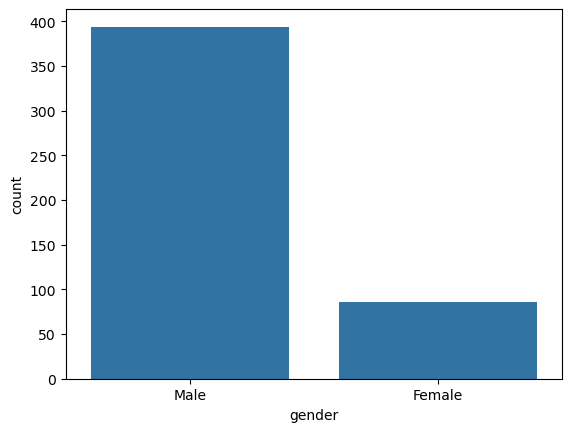

In [46]:
sns.countplot(x=df2.gender)

In [47]:
df2.head()

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
loan_id,,,,,,,,,,,,
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y


array([[<Axes: title={'center': 'applicantincome'}>, <Axes: title={'center': 'coapplicantincome'}>],
       [<Axes: title={'center': 'loanamount'}>, <Axes: title={'center': 'loan_amount_term'}>]], dtype=object)

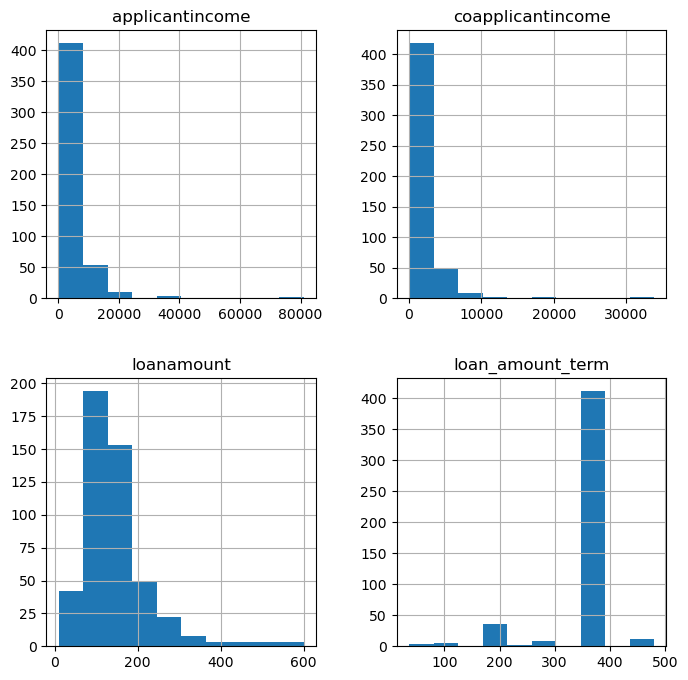

In [48]:


df2[['applicantincome', 'coapplicantincome', 'loanamount', 'loan_amount_term']].hist(figsize=(8,8))

<Axes: xlabel='loanamount', ylabel='Count'>

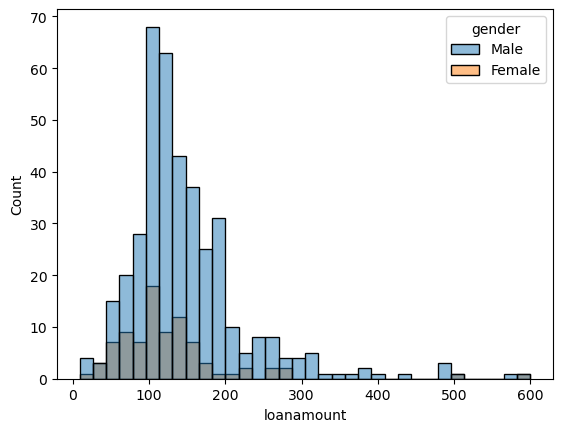

In [49]:
sns.histplot(x='loanamount', hue='gender', data=df2)

<Axes: xlabel='loanamount', ylabel='Count'>

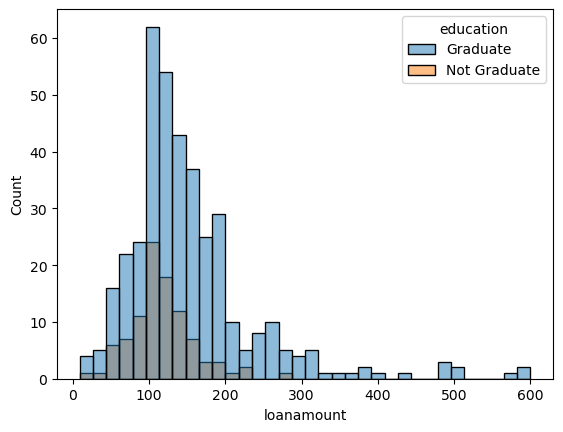

In [50]:
sns.histplot(x='loanamount', hue='education', data=df2)

<Axes: xlabel='loanamount', ylabel='Density'>

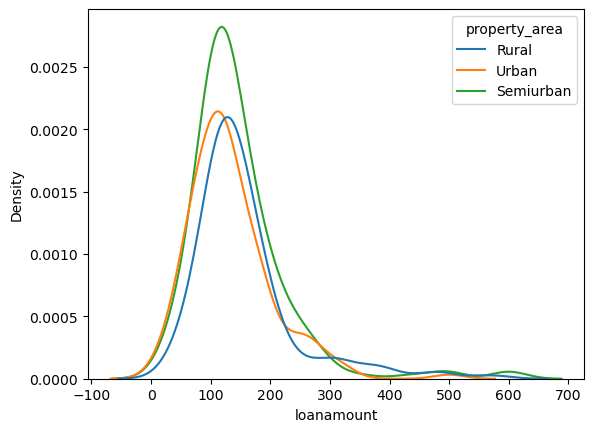

In [51]:
sns.kdeplot(x='loanamount', hue='property_area', data=df2)

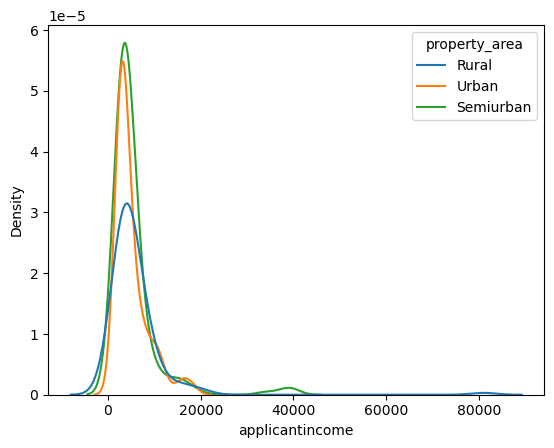

In [52]:
sns.kdeplot(x='applicantincome', hue='property_area', data=df2)
 
plt.show()

<Axes: xlabel='property_area', ylabel='applicantincome'>

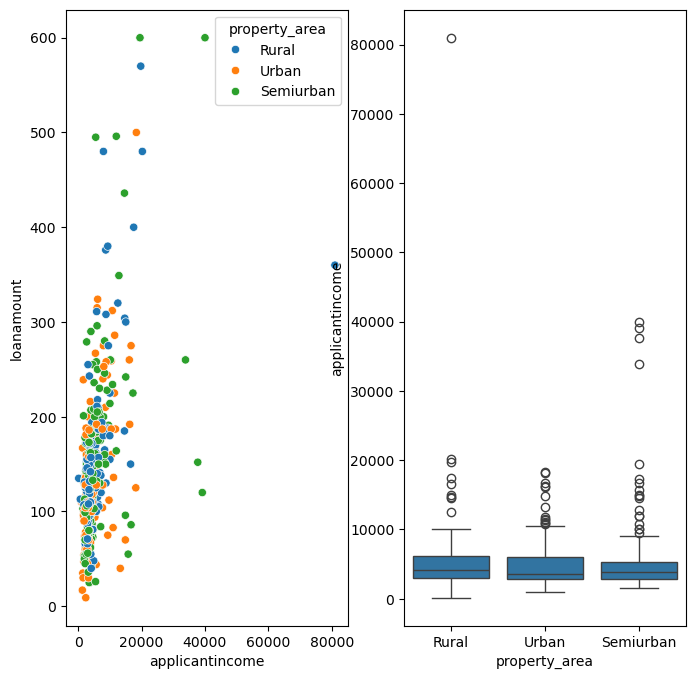

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(8,8))
sns.scatterplot(x='applicantincome', y='loanamount', data=df2, hue='property_area', ax=axes[0])
sns.boxplot(x='property_area', y='applicantincome', data=df2, ax=axes[1])

<Axes: xlabel='loan_status', ylabel='applicantincome'>

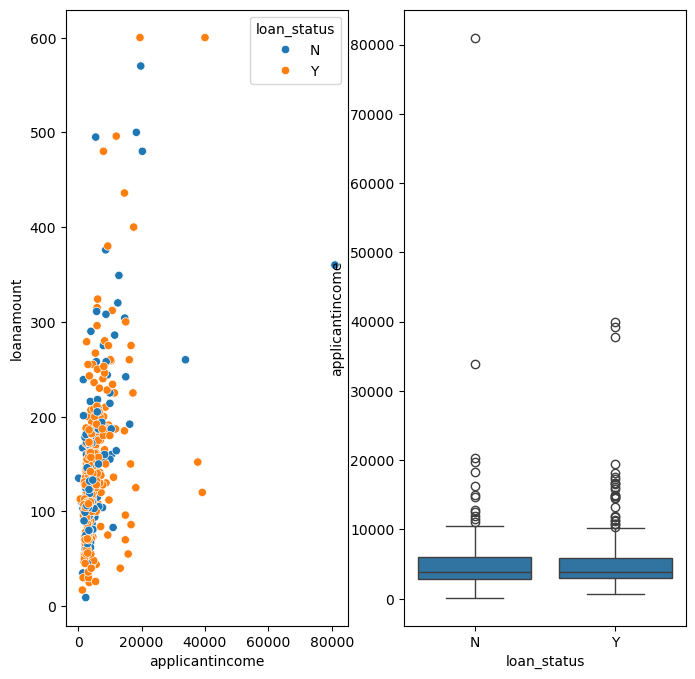

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(8,8))
sns.scatterplot(x='applicantincome', y='loanamount', data=df2, hue='loan_status', ax=axes[0])
sns.boxplot(x='loan_status', y='applicantincome', data=df2, ax=axes[1])

<Axes: xlabel='loan_status', ylabel='applicantincome'>

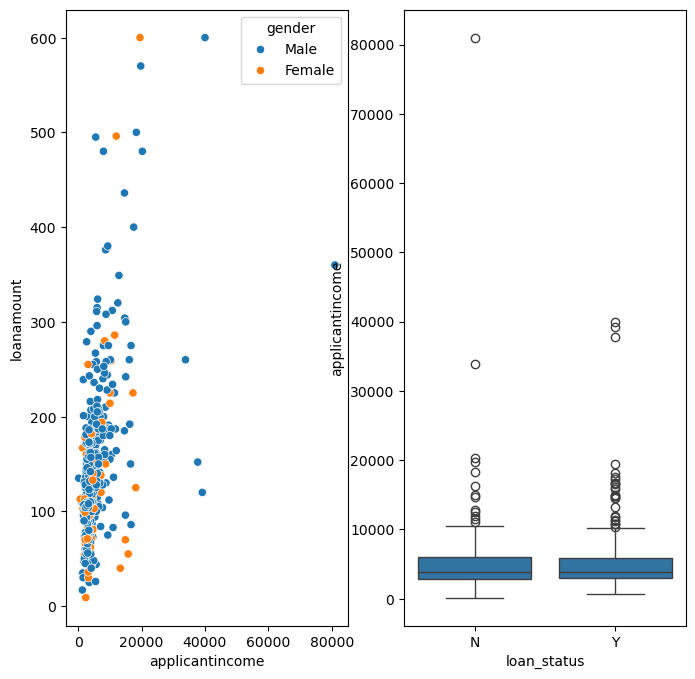

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(8,8))
sns.scatterplot(x='applicantincome', y='loanamount', data=df2, hue='gender', ax=axes[0])
sns.boxplot(x='loan_status', y='applicantincome', data=df2, ax=axes[1])

In [56]:
df.to_csv("data/loan_dataset.csv", index=False)


# Preprocessing

In [57]:
# Encoding the variables 
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 480 entries, LP001003 to LP002990
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             480 non-null    object 
 1   married            480 non-null    object 
 2   dependents         480 non-null    object 
 3   education          480 non-null    object 
 4   self_employed      480 non-null    object 
 5   applicantincome    480 non-null    int64  
 6   coapplicantincome  480 non-null    float64
 7   loanamount         480 non-null    float64
 8   loan_amount_term   480 non-null    float64
 9   credit_history     480 non-null    float64
 10  property_area      480 non-null    object 
 11  loan_status        480 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 64.9+ KB


In [58]:
df2.gender.unique()

array(['Male', 'Female'], dtype=object)

In [59]:
df2.married.unique()

array(['Yes', 'No'], dtype=object)

In [60]:
df2.education.unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [61]:
df2.self_employed.unique()

array(['No', 'Yes'], dtype=object)

In [62]:
df2.property_area.unique()

array(['Rural', 'Urban', 'Semiurban'], dtype=object)

In [63]:
df2.loan_status.unique()

array(['N', 'Y'], dtype=object)

In [64]:
df2.head()

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
loan_id,,,,,,,,,,,,
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y


In [65]:
from sklearn.preprocessing import LabelEncoder 
from category_encoders import WOEEncoder 

In [66]:
# Encoding the binary categories
le = LabelEncoder() 
df2['gender'] = le.fit_transform(df2['gender'])
df2['married'] = le.fit_transform(df2['married'])
df2['education'] = le.fit_transform(df2['education'])
df2['self_employed'] = le.fit_transform(df2['self_employed'])
df2['loan_status'] = le.fit_transform(df2['loan_status'])


<positron-console-cell-66>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<positron-console-cell-66>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<positron-console-cell-66>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<positron-console-cell-66>:6: SettingWithCopyW

In [67]:
df2

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
loan_id,,,,,,,,,,,,
LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,Rural,0
LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,Urban,1
LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,Urban,1
LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,Urban,1
LP001011,1,1,2,0,1,5417,4196.0,267.0,360.0,1.0,Urban,1
...,...,...,...,...,...,...,...,...,...,...,...,...
LP002978,0,0,0,0,0,2900,0.0,71.0,360.0,1.0,Rural,1
LP002979,1,1,3+,0,0,4106,0.0,40.0,180.0,1.0,Rural,1
LP002983,1,1,1,0,0,8072,240.0,253.0,360.0,1.0,Urban,1


In [68]:
df.head()

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [69]:
woe = WOEEncoder()
woe2 = WOEEncoder()
df2['property_area'] = woe.fit_transform(df2['property_area'], y=df2['loan_status'])
df2['dependents'] = woe2.fit_transform(df2['dependents'], y=df2['loan_status'])

<positron-console-cell-69>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<positron-console-cell-69>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [70]:
woe

WOEEncoder(cols=['property_area'])

In [71]:
import plotly.express as px
from sklearn.manifold import TSNE

In [72]:
tsne = TSNE(n_components=2, random_state=42)
df2_tsne = tsne.fit_transform(df2)

In [73]:
fig = px.scatter(x=df2_tsne[:, 0], y=df2_tsne[:, 1], color=df2.loan_status)
fig.update_layout(
    title="t-SNE visualization of Custom Classification dataset",
    xaxis_title="First t-SNE",
    yaxis_title="Second t-SNE",
)
fig.show()

# Model

to validate my findings, I will need to fit multiple models 

<b>tips:</b>
1. Optimise models using Grid-search
2. use tree-model feature importance
3. use SHAP
4. Make several sklearn pipelines

## Feature selection 

Here, I will use the Pearson Correlation Coefficient to check for multi-collinearity 

In [74]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

In [75]:
## checking the test dataset 
test

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,NaN,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural


In [76]:
df2.columns

Index(['gender', 'married', 'dependents', 'education', 'self_employed', 'applicantincome', 'coapplicantincome', 'loanamount',
       'loan_amount_term', 'credit_history', 'property_area', 'loan_status'],
      dtype='object')

In [77]:
df.property_area.unique()

array(['Urban', 'Rural', 'Semiurban'], dtype=object)

In [78]:
X = df2.drop(['loan_status', 'dependents', 'married', 'gender', 'self_employed'], axis=1) 
y = df2.loan_status.values.reshape(-1,1)

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2) 

## Example 




In [79]:
## Feature selection using Pearson Correlation Coefficient 

from sklearn.feature_selection import r_regression

r_regression(X, y)

/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



array([-0.0684372 , -0.04315159, -0.04901952, -0.07175255, -0.0077976 ,  0.52938975,  0.15954146])

In [80]:
X.columns

Index(['education', 'applicantincome', 'coapplicantincome', 'loanamount', 'loan_amount_term', 'credit_history', 'property_area'], dtype='object')

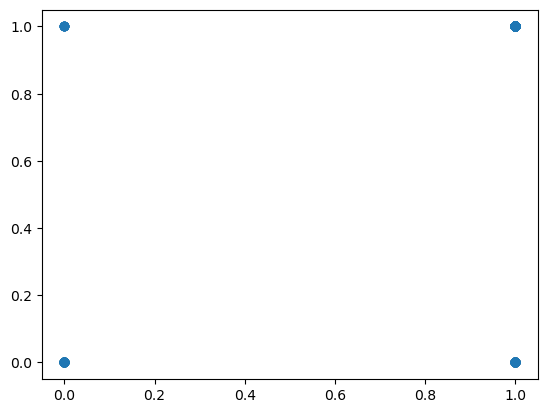

In [81]:
plt.scatter(X.credit_history, y)

In [82]:
X

,education,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area
loan_id,,,,,,,
LP001003,0,4583,1508.0,128.0,360.0,1.0,-0.353492
LP001005,0,3000,0.0,66.0,360.0,1.0,-0.175678
LP001006,1,2583,2358.0,120.0,360.0,1.0,-0.175678
LP001008,0,6000,0.0,141.0,360.0,1.0,-0.175678
LP001011,0,5417,4196.0,267.0,360.0,1.0,-0.175678
...,...,...,...,...,...,...,...
LP002978,0,2900,0.0,71.0,360.0,1.0,-0.353492
LP002979,0,4106,0.0,40.0,180.0,1.0,-0.353492
LP002983,0,8072,240.0,253.0,360.0,1.0,-0.175678


## Model Optimisation

In [83]:
from skopt import BayesSearchCV


Optimising Xgboost

In [84]:
# Optimising Xgboost 
model = XGBClassifier() 
grid_values = {'max_depth': [4, 5, 6, 7, 8, 9, 10], 'booster': ['dart', 'gbtree', 'gblinear'],
               'eta': [0.001, 0.01, 0.1], 'tree_method': ['exact', 'approx', 'hist']}



bay_model_xgboost = BayesSearchCV(estimator=model,
                    search_spaces=grid_values,
                    n_iter=25,
                    cv=5,
                    n_jobs=8,
                    scoring='f1',
                    random_state=123)

bay_model_xgboost.fit(X_train, Y_train)
pred = bay_model_xgboost.predict(X_test)

/opt/miniconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [23:29:43] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1722296451054/work/src/learner.cc:740: 
Parameters: { "max_depth", "tree_method" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/miniconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [23:29:43] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1722296451054/work/src/learner.cc:740: 
Parameters: { "max_depth", "tree_method" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/miniconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [23:29:43] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1722296451054/work/src/learner.cc:740: 
Parameters: { "max_depth", "tree_method" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/miniconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [23:29:43] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_172229645

In [85]:
bay_model_xgboost.best_params_

OrderedDict([('booster', 'gblinear'),
             ('eta', 0.1),
             ('max_depth', 9),
             ('tree_method', 'exact')])

In [86]:
optimised_xgboost_model = XGBClassifier(booster='gblinear', eta=0.1, max_depth=9, tree_method='exact')
optimised_xgboost_model.fit(X_train, Y_train) 
optimised_xgboost_predictions = optimised_xgboost_model.predict(X_test)

joblib.dump(optimised_xgboost_model, 'model/optimised_xgboost_model.pkl')

/opt/miniconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning:

[23:29:52] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1722296451054/work/src/learner.cc:740: 
Parameters: { "max_depth", "tree_method" } are not used.




NameError: name 'joblib' is not defined

Optimising Random Forest

In [87]:
# Optimising RandomForest 
model2 = RandomForestClassifier() 
grid_values = {'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'verbose': [1],
               'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'n_estimators': [200, 400, 600]}



bay_model_random_forest = BayesSearchCV(estimator=model2,
                    search_spaces=grid_values,
                    n_iter=25,
                    cv=5,
                    n_jobs=8,
                    scoring='f1',
                    random_state=123)

bay_model_random_forest.fit(X_train, Y_train)
pred2 = bay_model_random_forest.predict(X_test)


/opt/miniconda3/lib/python3.11/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/miniconda3/lib/python3.11/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/miniconda3/lib/python3.11/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/miniconda3/lib/python3.11/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_sample

In [88]:
bay_model_random_forest.best_params_

OrderedDict([('max_depth', 8),
             ('min_samples_leaf', 9),
             ('n_estimators', 400),
             ('verbose', 1)])

In [89]:
optimised_random_forest = RandomForestClassifier(n_estimators=600, max_depth=10, min_samples_leaf=3, verbose=1)
optimised_random_forest.get_params

<bound method BaseEstimator.get_params of RandomForestClassifier(max_depth=10, min_samples_leaf=3, n_estimators=600,
                       verbose=1)>

In [90]:
optimised_random_forest.fit(X_train, Y_train) 
optimised_forest_pred = optimised_random_forest.predict(X_test)
joblib.dump(optimised_random_forest, 'optimised_random_forest_model.pkl')

/opt/miniconda3/lib/python3.11/site-packages/sklearn/base.py:1473: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s


NameError: name 'joblib' is not defined

In [91]:
from sklearn.feature_selection import SelectFromModel

feature_selected_model = SelectFromModel(model2, prefit=True)



In [92]:
feature_selected_model

SelectFromModel(estimator=RandomForestClassifier(), prefit=True)

In [93]:
df.property_area.unique()

array(['Urban', 'Rural', 'Semiurban'], dtype=object)

In [94]:
df.education.unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [95]:
df.loan_amount_term.unique()

array([360., 120., 240.,  nan, 180.,  60., 300., 480.,  84.,  12., 350.,  36.,   6.])

In [96]:
bay_model_random_forest.best_params_

OrderedDict([('max_depth', 8),
             ('min_samples_leaf', 9),
             ('n_estimators', 400),
             ('verbose', 1)])

Optimising Logistic Regression

In [97]:
## Grid search csv
## Optimising the Logistic Regression 
model3 = LogisticRegression()
grid_values = {'penalty': ['l2'],'C':[0.001,.009,0.01,.09,1,5,10,25]}




bay_model_logistic = BayesSearchCV(estimator=model3,
                    search_spaces=grid_values,
                    n_iter=25,
                    cv=5,
                    n_jobs=8,
                    scoring='f1',
                    random_state=123)

bay_model_logistic.fit(X_train, Y_train)
pred3 = bay_model_logistic.predict(X_test)

/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/miniconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logis

In [98]:
bay_model_logistic.best_params_

OrderedDict([('C', 10), ('penalty', 'l2')])

In [99]:
optimised_logistic_model = LogisticRegression(C=10, penalty='l2') 
optimised_logistic_model.fit(X_train, Y_train) 
optimised_logistic_predictions = optimised_logistic_model.predict(X_test)
joblib.dump(optimised_logistic_model, 'optimised_logistic_model.pkl')

/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/opt/miniconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



NameError: name 'joblib' is not defined

# Metrics

In [100]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score 
from sklearn.metrics import recall_score 
from sklearn.metrics import precision_score 
from sklearn.metrics import roc_auc_score

In [101]:
def generate_metrics(predictions): 
    print (f"accuracy: {accuracy_score(Y_test, predictions)}")
    print (f"f1 score: {f1_score(Y_test, predictions)}")
    print (f"recall score: {recall_score(Y_test, predictions)}")
    print (f"precision score: {precision_score(Y_test, predictions)}")
    print (f"roc auc: {roc_auc_score(Y_test, predictions)}")
    
    ## Generating an ROC curve
    

In [102]:
# Xgboost 
generate_metrics(optimised_xgboost_predictions)

accuracy: 0.84375
f1 score: 0.9019607843137255
recall score: 0.9857142857142858
precision score: 0.8313253012048193
roc auc: 0.7236263736263737


In [103]:
# Random Forest
generate_metrics(optimised_forest_pred)

accuracy: 0.8333333333333334
f1 score: 0.8933333333333333
recall score: 0.9571428571428572
precision score: 0.8375
roc auc: 0.7285714285714286


In [104]:
# Logistic Regression
generate_metrics(optimised_logistic_predictions)

accuracy: 0.84375
f1 score: 0.9019607843137255
recall score: 0.9857142857142858
precision score: 0.8313253012048193
roc auc: 0.7236263736263737


## Cross validation

In [105]:
from sklearn.model_selection import cross_validate

In [149]:
# LOGISTIC

scoring = ['f1', 'accuracy', 'recall', 'precision']


logistic_scores = cross_validate(optimised_logistic_model, X, y, scoring=scoring)

/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/opt/miniconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/opt/miniconda3/lib/python3.11/site-packages/

In [150]:
logistic_scores

{'fit_time': array([0.01029611, 0.00807619, 0.01009202, 0.00601387, 0.00565195]),
 'score_time': array([0.00389194, 0.0030899 , 0.00285602, 0.00395107, 0.00229502]),
 'test_f1': array([0.87248322, 0.8590604 , 0.85333333, 0.91666667, 0.87671233]),
 'test_accuracy': array([0.80208333, 0.78125   , 0.77083333, 0.875     , 0.8125    ]),
 'test_recall': array([0.98484848, 0.96969697, 0.96969697, 0.98507463, 0.95522388]),
 'test_precision': array([0.78313253, 0.77108434, 0.76190476, 0.85714286, 0.81012658])}

In [151]:
# XGBOOST
scoring = ['f1', 'accuracy', 'recall', 'precision']


xgboost_scores = cross_validate(optimised_xgboost_model, X, y, scoring=scoring)

/opt/miniconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning:

[23:32:03] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1722296451054/work/src/learner.cc:740: 
Parameters: { "max_depth", "tree_method" } are not used.


/opt/miniconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning:

[23:32:03] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1722296451054/work/src/learner.cc:740: 
Parameters: { "max_depth", "tree_method" } are not used.


/opt/miniconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning:

[23:32:03] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1722296451054/work/src/learner.cc:740: 
Parameters: { "max_depth", "tree_method" } are not used.


/opt/miniconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning:

[23:32:03] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1722296451054/work/src/learner.cc:740: 
Parameters: { "max_depth", "tree_method" } are not used.


/opt/min

In [152]:
xgboost_scores

{'fit_time': array([0.014184  , 0.01332092, 0.0111587 , 0.00912905, 0.0096159 ]),
 'score_time': array([0.00495601, 0.00536108, 0.00328517, 0.0030179 , 0.00318193]),
 'test_f1': array([0.87248322, 0.8590604 , 0.85333333, 0.92307692, 0.87671233]),
 'test_accuracy': array([0.80208333, 0.78125   , 0.77083333, 0.88541667, 0.8125    ]),
 'test_recall': array([0.98484848, 0.96969697, 0.96969697, 0.98507463, 0.95522388]),
 'test_precision': array([0.78313253, 0.77108434, 0.76190476, 0.86842105, 0.81012658])}

In [153]:
# RANDOM FOREST
scoring = ['f1', 'accuracy', 'recall', 'precision']


random_forest_scores = cross_validate(optimised_random_forest, X, y, scoring=scoring)

/opt/miniconda3/lib/python3.11/site-packages/sklearn/base.py:1473: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
/opt/miniconda3/lib/python3.11/site-packages/sklearn/base.py:1473: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.2s
[Pa

In [154]:
random_forest_scores

{'fit_time': array([0.33661532, 0.32901287, 0.34050512, 0.32672882, 0.31681323]),
 'score_time': array([0.014323  , 0.01361823, 0.01487708, 0.01415205, 0.01352382]),
 'test_f1': array([0.87837838, 0.85714286, 0.85333333, 0.88235294, 0.8630137 ]),
 'test_accuracy': array([0.8125    , 0.78125   , 0.77083333, 0.83333333, 0.79166667]),
 'test_recall': array([0.98484848, 0.95454545, 0.96969697, 0.89552239, 0.94029851]),
 'test_precision': array([0.79268293, 0.77777778, 0.76190476, 0.86956522, 0.79746835])}

In [171]:
len(random_forest_scores.values())

6

In [175]:
# PLotting them together
# I could put all of the metrics into one dataframe 

label1 = ['logistic_regression' for i in range(5)]
label2 = ['xgboost' for i in range(5)]
label3 = ['random_forest' for i in range(5)]
cross_validation_metrics = pd.DataFrame({
    'model': [*label1, *label2, *label3],
    'fit_time': [*logistic_scores['test_f1'], *xgboost_scores['test_f1'], *random_forest_scores['test_f1']],
    'score_time': [*logistic_scores['score_time'], *xgboost_scores['score_time'], *random_forest_scores['score_time']],
    'f1_score': [*logistic_scores['test_f1'], *xgboost_scores['test_f1'], *random_forest_scores['test_f1']],
    'test_accuracy': [*logistic_scores['test_accuracy'], *xgboost_scores['test_accuracy'], *random_forest_scores['test_accuracy']],
    'test_recall': [*logistic_scores['test_recall'], *xgboost_scores['test_recall'], *random_forest_scores['test_recall']],
    'test_precision': [*logistic_scores['test_precision'], *xgboost_scores['test_precision'], *random_forest_scores['test_precision']]

})



In [176]:
cross_validation_metrics

,model,fit_time,score_time,f1_score,test_accuracy,test_recall,test_precision
0,logistic_regression,0.872483,0.003892,0.872483,0.802083,0.984848,0.783133
1,logistic_regression,0.859060,0.003090,0.859060,0.781250,0.969697,0.771084
2,logistic_regression,0.853333,0.002856,0.853333,0.770833,0.969697,0.761905
3,logistic_regression,0.916667,0.003951,0.916667,0.875000,0.985075,0.857143
4,logistic_regression,0.876712,0.002295,0.876712,0.812500,0.955224,0.810127
5,xgboost,0.872483,0.004956,0.872483,0.802083,0.984848,0.783133
6,xgboost,0.859060,0.005361,0.859060,0.781250,0.969697,0.771084
7,xgboost,0.853333,0.003285,0.853333,0.770833,0.969697,0.761905
8,xgboost,0.923077,0.003018,0.923077,0.885417,0.985075,0.868421
9,xgboost,0.876712,0.003182,0.876712,0.812500,0.955224,0.810127


<Axes: >

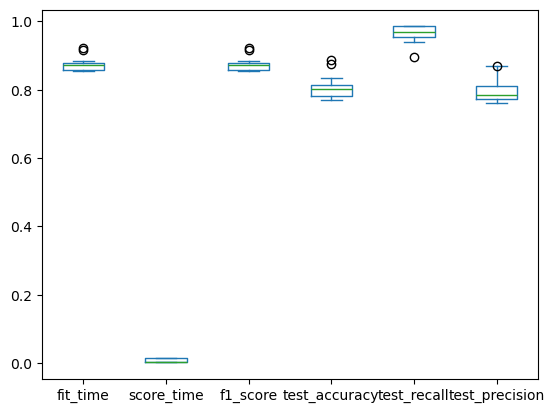

In [185]:
## plotting the metrics 

cross_validation_metrics[['fit_time', 'score_time', 'f1_score', 'test_accuracy', 'test_recall', 'test_precision']].plot(kind='box')   

In [190]:
cross_validation_metrics2 = pd.melt(cross_validation_metrics, id_vars='model')


In [195]:
cross_validation_metrics2.rename({'variable': "metric"}, inplace=True)

In [196]:
cross_validation_metrics2

,model,variable,value
0,logistic_regression,fit_time,0.872483
1,logistic_regression,fit_time,0.859060
2,logistic_regression,fit_time,0.853333
3,logistic_regression,fit_time,0.916667
4,logistic_regression,fit_time,0.876712
...,...,...,...
85,random_forest,test_precision,0.792683
86,random_forest,test_precision,0.777778
87,random_forest,test_precision,0.761905
88,random_forest,test_precision,0.869565


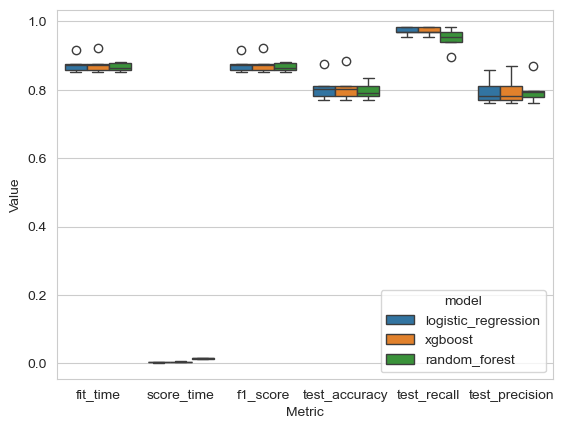

In [201]:
sns.set_style("whitegrid")

sns.boxplot(x='variable', y='value', hue='model', data=cross_validation_metrics2)

plt.xlabel("Metric")
plt.ylabel("Value") 

plt.show()

# Explanation

Create models with the parameters suggested by bayes search

It is important to note that for <b>loan_status</b>:
- 0 = N
- 1 = Y 

In [107]:
df2.loan_status

loan_id
LP001003    0
LP001005    1
LP001006    1
LP001008    1
LP001011    1
           ..
LP002978    1
LP002979    1
LP002983    1
LP002984    1
LP002990    0
Name: loan_status, Length: 480, dtype: int64

In [108]:
import shap 

In [109]:
def explain_predictions(model, predictions): 
    explainer = shap.Explainer(model, X)
    shap_values = explainer.shap_values(X_test)
    shap.summary_plot(shap_values, X_test)
    
    


Explaining Xgboost

In [110]:
bay_model_xgboost.best_params_

OrderedDict([('booster', 'gblinear'),
             ('eta', 0.1),
             ('max_depth', 9),
             ('tree_method', 'exact')])

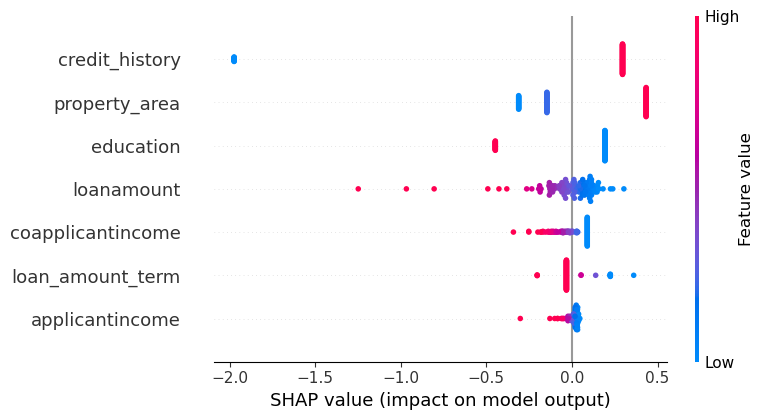

In [111]:
explain_predictions(optimised_xgboost_model, optimised_xgboost_predictions)



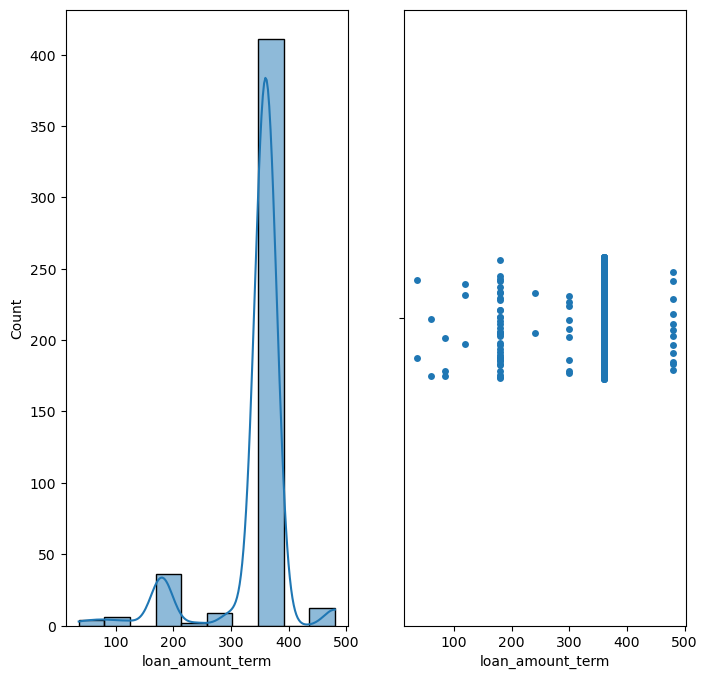

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(8,8))
sns.histplot(x='loan_amount_term', data=df2, kde=True, ax=axes[0]) 
sns.stripplot(x='loan_amount_term', data=df2, ax=axes[1])
plt.show()



Explaining Logistic Regression

In [113]:
bay_model_logistic.best_params_

OrderedDict([('C', 10), ('penalty', 'l2')])

In [114]:
logistic_model = LogisticRegression(C=1, penalty='l2')
logistic_model.fit(X_train, Y_train)

/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/opt/miniconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression(C=1)

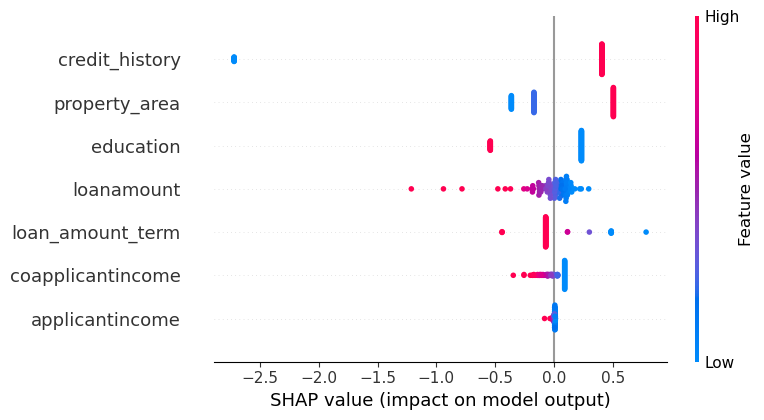

<Figure size 640x480 with 0 Axes>

In [115]:
explain_predictions(optimised_logistic_model, optimised_logistic_predictions)
plt.savefig("shap_plot.png")

In [116]:
df2.education

loan_id
LP001003    0
LP001005    0
LP001006    1
LP001008    0
LP001011    0
           ..
LP002978    0
LP002979    0
LP002983    0
LP002984    0
LP002990    0
Name: education, Length: 480, dtype: int64

Explaining Random Forest Classifier

In [117]:
bay_model_random_forest.best_params_

OrderedDict([('max_depth', 8),
             ('min_samples_leaf', 9),
             ('n_estimators', 400),
             ('verbose', 1)])

In [118]:
forest_model = RandomForestClassifier(max_depth=10, min_samples_leaf=8, n_estimators=600)
forest_model.fit(X_train, Y_train)

/opt/miniconda3/lib/python3.11/site-packages/sklearn/base.py:1473: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



RandomForestClassifier(max_depth=10, min_samples_leaf=8, n_estimators=600)

In [119]:
df2.married

loan_id
LP001003    1
LP001005    1
LP001006    1
LP001008    0
LP001011    1
           ..
LP002978    0
LP002979    1
LP002983    1
LP002984    1
LP002990    0
Name: married, Length: 480, dtype: int64

# Conclusions


<b>notes:</b>
- Semi-urban was encoded the highest, Rural is the lowest, urban is the middle 
- Married: 1 = Yes, 0 = No


## Findings
1. All models agreed with each other 
2. Loan amount, applicant income, co-applicant income, loan term inversely correlated with acceptance liklihood
3. males are slightly more likely to be accepted than females
4. Graduates are more likely to be accepted for a loan (education is important!)
5. dependents, gender, self-employed status and applicant income are the lowest predictors of loan status
6. Urban areas are the most likely to be accepted for a loan, followed by semi-urban and then rural properties
7. Married people are more likely to be granted a loan

## Concordant papers



## Limitations
1. Low sample size (many samples deleted)
2. Data was found on kaggle with no DOI citation 
3. 

# Saving the Model

In [120]:
import joblib 



In [121]:
# saving the xgboost model 

joblib.dump(bay_model_xgboost, 'model/xgboost_loan_prediction.pkl')

['model/xgboost_loan_prediction.pkl']

In [122]:
# saving the random forest model
joblib.dump(bay_model_random_forest, 'model/random_forest_loan_prediction.pkl')

['model/random_forest_loan_prediction.pkl']

In [123]:
# saving the logistic regression model 

joblib.dump(bay_model_logistic, 'model/logistic_regression_loan_prediction.pkl')

['model/logistic_regression_loan_prediction.pkl']

# Saving the preprocessing steps

In [124]:
joblib.dump(X_test, "X_test.pkl") 


['X_test.pkl']

In [125]:
a = joblib.load("X_test.pkl")
a

,education,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area
loan_id,,,,,,,
LP002422,0,37719,0.0,152.0,360.0,1.0,0.448929
LP002224,0,3069,0.0,71.0,480.0,1.0,-0.175678
LP001630,1,2333,1451.0,102.0,480.0,0.0,-0.175678
LP002473,0,8334,0.0,160.0,360.0,1.0,0.448929
LP001206,0,3029,0.0,99.0,360.0,1.0,-0.175678
...,...,...,...,...,...,...,...
LP002586,0,3326,913.0,105.0,84.0,1.0,0.448929
LP001884,0,2876,1560.0,90.0,360.0,1.0,-0.175678
LP001112,0,3667,1459.0,144.0,360.0,1.0,0.448929


In [126]:
df2

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
loan_id,,,,,,,,,,,,
LP001003,1,1,-0.197510,0,0,4583,1508.0,128.0,360.0,1.0,-0.353492,0
LP001005,1,1,-0.041401,0,1,3000,0.0,66.0,360.0,1.0,-0.175678,1
LP001006,1,1,-0.041401,1,0,2583,2358.0,120.0,360.0,1.0,-0.175678,1
LP001008,1,0,-0.041401,0,0,6000,0.0,141.0,360.0,1.0,-0.175678,1
LP001011,1,1,0.344627,0,1,5417,4196.0,267.0,360.0,1.0,-0.175678,1
...,...,...,...,...,...,...,...,...,...,...,...,...
LP002978,0,0,-0.041401,0,0,2900,0.0,71.0,360.0,1.0,-0.353492,1
LP002979,1,1,-0.072267,0,0,4106,0.0,40.0,180.0,1.0,-0.353492,1
LP002983,1,1,-0.197510,0,0,8072,240.0,253.0,360.0,1.0,-0.175678,1


In [127]:
df2.to_csv("data/cleaned_loan_dataset.csv")


<Axes: xlabel='loan_status', ylabel='count'>

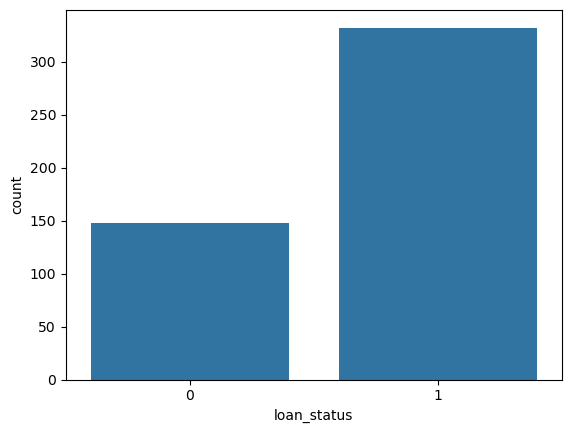

In [128]:
sns.countplot(x='loan_status', data=df2)

In [129]:
df2.loan_status.value_counts()

loan_status
1    332
0    148
Name: count, dtype: int64

In [130]:
(148 / (142 + 332)) * 100

31.223628691983123

In [131]:
X

,education,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area
loan_id,,,,,,,
LP001003,0,4583,1508.0,128.0,360.0,1.0,-0.353492
LP001005,0,3000,0.0,66.0,360.0,1.0,-0.175678
LP001006,1,2583,2358.0,120.0,360.0,1.0,-0.175678
LP001008,0,6000,0.0,141.0,360.0,1.0,-0.175678
LP001011,0,5417,4196.0,267.0,360.0,1.0,-0.175678
...,...,...,...,...,...,...,...
LP002978,0,2900,0.0,71.0,360.0,1.0,-0.353492
LP002979,0,4106,0.0,40.0,180.0,1.0,-0.353492
LP002983,0,8072,240.0,253.0,360.0,1.0,-0.175678


# The Entire Pipeline

In [132]:
100e4


1000000.0

In [133]:
joblib.dump(woe, 'property_area_woe.pkl')
joblib.dump(woe3, 'dependents_woe.pkl')

NameError: name 'woe3' is not defined

In [134]:
pred

array([1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1])

In [135]:
explainer = shap.Explainer(model, X_test)

TypeError: The passed model is not callable and cannot be analyzed directly with the given masker! Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [136]:
explainer = shap.Explainer(optimised_random_forest, X_test)
shap_values = explainer(X_test)

In [137]:
shap_values.values

array([[[-0.00054008,  0.00054008],
        [ 0.13914441, -0.13914441],
        [ 0.03809187, -0.03809187],
        ...,
        [-0.00241209,  0.00241209],
        [-0.06744219,  0.06744219],
        [-0.00857706,  0.00857706]],

       [[-0.01364787,  0.01364787],
        [-0.02754572,  0.02754572],
        [ 0.0341138 , -0.0341138 ],
        ...,
        [ 0.08388336, -0.08388336],
        [-0.07702237,  0.07702237],
        [ 0.03339485, -0.03339486]],

       [[ 0.01067411, -0.01067411],
        [-0.00201314,  0.00201314],
        [-0.0157422 ,  0.0157422 ],
        ...,
        [ 0.03498937, -0.03498937],
        [ 0.50400553, -0.50400553],
        [ 0.02543723, -0.02543723]],

       ...,

       [[-0.00853431,  0.00853431],
        [-0.02069213,  0.02069213],
        [-0.02409726,  0.02409726],
        ...,
        [-0.0084799 ,  0.0084799 ],
        [-0.08368792,  0.08368792],
        [-0.03970465,  0.03970465]],

       [[-0.00250015,  0.00250015],
        [-0.00328161,  0.00

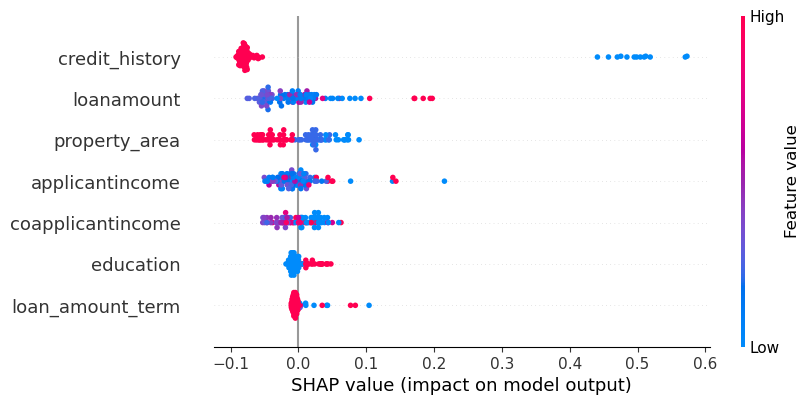

In [138]:
shap.plots.beeswarm(shap_values[:, :, 0])

In [139]:
joblib.dump(shap_values, 'random_forest_shap_values.pkl')

['random_forest_shap_values.pkl']

In [140]:
optimised_logistic_predictions

array([1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1])

In [141]:
model = joblib.load("model/optimised_random_forest_model.pkl")

In [142]:
model.predict(X_test)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s


array([1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1])

In [143]:
test = np.array([0, 0, 0, 0, 0, 0, 0])
test2 = np.reshape(test, (1,-1)) 

model.predict(test2)

/opt/miniconda3/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but RandomForestClassifier was fitted with feature names

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s


array([0])